# YOLOv8 Vegetable Classification for XIAO ESP32S3

Train YOLOv8n-cls to classify 10 common fridge vegetables, then convert to TFLite INT8 for ESP32S3 deployment.

In [ ]:
# Cell 1: Install and Import
!conda install -y pytorch torchvision -c pytorch && pip install ultralytics

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Configuration
IMG_SIZE = 96
EPOCHS = 50
BATCH_SIZE = 32
CONFIDENCE_THRESHOLD = 0.6
NUM_CLASSES = 10

SELECTED_CLASSES = [
    'Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber',
    'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato'
]

BASE_DIR = Path('..') / 'data' / 'huggingface'
TRAIN_DIR = BASE_DIR / 'Train'
VAL_DIR = BASE_DIR / 'val'

# YOLO needs a specific directory structure:
# dataset/train/class_name/images...
# dataset/val/class_name/images...
YOLO_DATASET = Path('yolo_dataset')

print(f'Selected classes: {SELECTED_CLASSES}')

Selected classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato']


In [2]:
# Cell 2: Prepare YOLO Dataset (copy selected 10 classes into yolo_dataset/)

for split, src_dir in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    for cls in SELECTED_CLASSES:
        dst = YOLO_DATASET / split / cls
        src = src_dir / cls
        # If a previous run left a symlink here, remove it so we can copy fresh files
        if dst.is_symlink():
            dst.unlink()
        if dst.exists():
            continue
        dst.parent.mkdir(parents=True, exist_ok=True)
        # Copy the class folder into yolo_dataset/ (independent copy, no symlinks)
        shutil.copytree(src, dst)
        print(f'Copied: {src} -> {dst}')

# Verify
print('\n=== Dataset Summary ===')
for split in ['train', 'val']:
    split_dir = YOLO_DATASET / split
    total = 0
    for cls in sorted(os.listdir(split_dir)):
        count = len(list((split_dir / cls).glob('*')))
        total += count
        print(f'  {split}/{cls}: {count} images')
    print(f'  Total {split}: {total}\n')


=== Dataset Summary ===
  train/Bellpepper: 90 images
  train/Broccoli: 80 images
  train/Cabbage: 92 images
  train/Carrot: 82 images
  train/Cucumber: 94 images
  train/Eggplant: 84 images
  train/Garlic: 92 images
  train/Onion: 94 images
  train/Potato: 77 images
  train/Tomato: 92 images
  Total train: 877

  val/Bellpepper: 9 images
  val/Bellpepper.cache: 0 images
  val/Broccoli: 17 images
  val/Cabbage: 10 images
  val/Carrot: 9 images
  val/Cucumber: 10 images
  val/Eggplant: 10 images
  val/Garlic: 10 images
  val/Onion: 10 images
  val/Potato: 10 images
  val/Tomato: 10 images
  Total val: 105



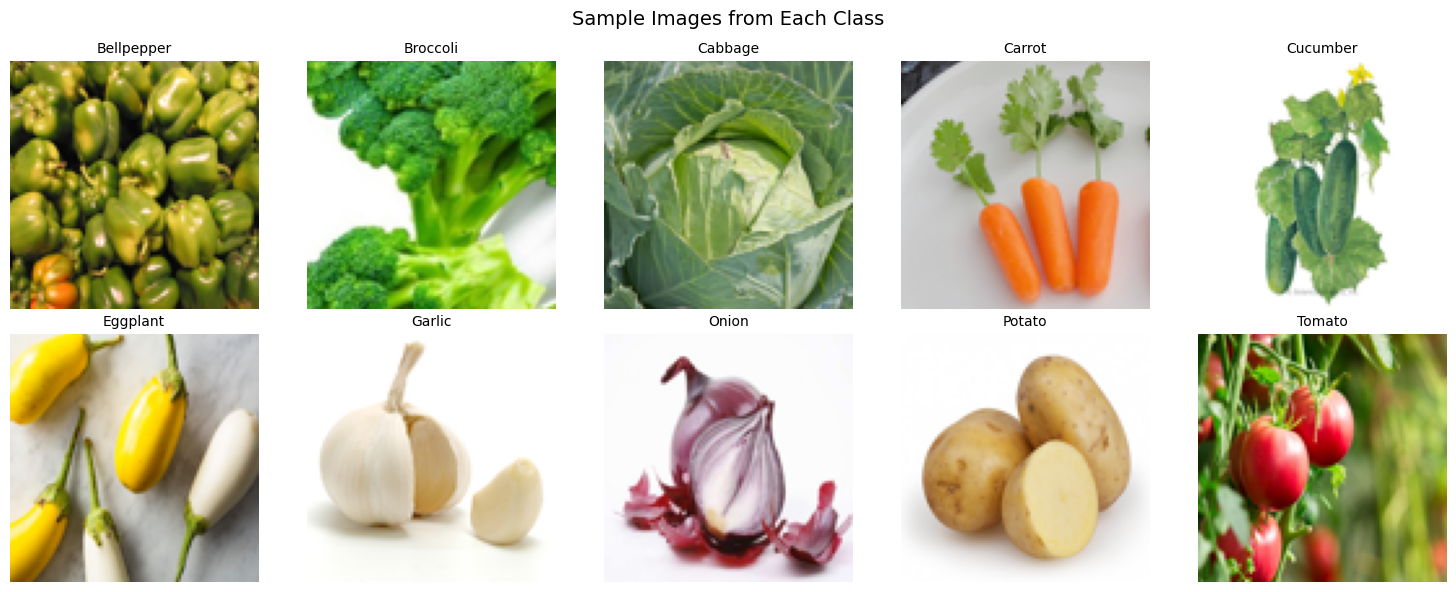

In [3]:
# Cell 3: Visualize Sample Images

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(SELECTED_CLASSES):
    ax = axes[i // 5, i % 5]
    cls_path = YOLO_DATASET / 'train' / cls
    img_path = list(cls_path.glob('*'))[0]
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4: Train YOLOv8n-cls

# Load pretrained YOLOv8 nano classification model
model = YOLO('yolov8n-cls.pt')

# Train on our 10-class vegetable dataset
results = model.train(
    data=str(YOLO_DATASET.resolve()),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device='cpu',        # Use 'mps' for Apple Silicon GPU, 'cuda' for NVIDIA
    workers=2,
    project='runs',
    name='veggie_yolo',
    exist_ok=True,
    pretrained=True,
    optimizer='Adam',
    lr0=0.001,
    patience=15,         # Early stopping patience
    verbose=True
)

In [ ]:
# Cell 5: Training Visualization

# YOLO saves training plots automatically
results_dir = Path('runs/veggie_yolo')

# Display YOLO's built-in training plots
for plot_name in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']:
    plot_path = results_dir / plot_name
    if plot_path.exists():
        img = Image.open(plot_path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(plot_name)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

In [4]:
# Cell 6: Evaluate on Validation Set

# Load best model
best_model = YOLO('runs/classify/runs/veggie_yolo/weights/best.pt')

# Run validation
metrics = best_model.val(
    data=str(YOLO_DATASET.resolve()),
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    split='val'
)

print(f'\nTop-1 Accuracy: {metrics.top1:.4f}')
print(f'Top-5 Accuracy: {metrics.top5:.4f}')

Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.11.0 CPU (Apple M3)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/train... found 877 images in 10 classes ✅ 
val: /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/val... found 105 images in 10 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1212.8±1257.5 MB/s, size: 1645.2 KB)
val: Scanning /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/val... 105 images, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 21.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 2.1it/s 1.9s0.9s
                   all      0.971          1
Speed: 0.0ms preprocess, 2.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/runs/classify/val2

Top-1 Accuracy: 0.9714
Top-5 Accuracy: 1.000

Predictions below threshold (0.6): 1/105
These would be "Object not known"

=== Classification Report (confident predictions) ===
              precision    recall  f1-score   support

  Bellpepper       1.00      1.00      1.00         9
    Broccoli       1.00      0.94      0.97        16
     Cabbage       0.91      1.00      0.95        10
      Carrot       1.00      1.00      1.00         9
    Cucumber       0.91      1.00      0.95        10
    Eggplant       0.91      1.00      0.95        10
      Garlic       1.00      1.00      1.00        10
       Onion       1.00      1.00      1.00        10
      Potato       1.00      0.80      0.89        10
      Tomato       1.00      1.00      1.00        10

    accuracy                           0.97       104
   macro avg       0.97      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

=== Classification Report (all predictions) ===
              precision    recall  f1-score   support

  Bellpe

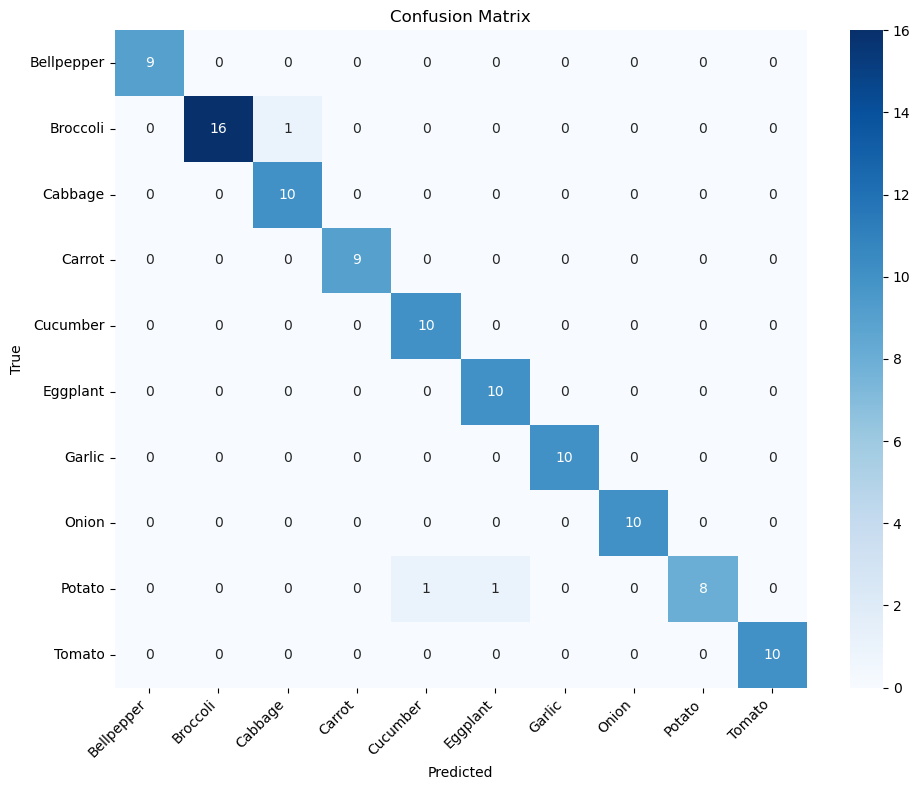

Overall accuracy: 0.9714


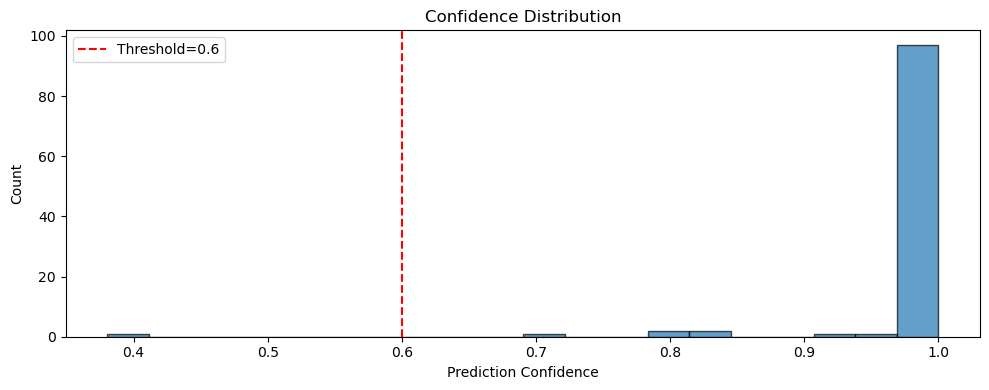

In [7]:
# Cell 7: Detailed Per-Class Evaluation with Confidence Threshold

# Predict on each val image individually to get confidence scores
y_true = []
y_pred = []
y_conf = []

class_names = sorted(os.listdir(YOLO_DATASET / 'val'))
all_labels = list(range(len(class_names)))

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = YOLO_DATASET / 'val' / cls_name
    for img_path in cls_dir.glob('*'):
        result = best_model.predict(str(img_path), imgsz=IMG_SIZE, verbose=False)[0]
        probs = result.probs
        y_true.append(cls_idx)
        y_pred.append(probs.top1)
        y_conf.append(probs.top1conf.item())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

# Apply confidence threshold
unknown_mask = y_conf < CONFIDENCE_THRESHOLD
confident_mask = ~unknown_mask

print(f'Predictions below threshold ({CONFIDENCE_THRESHOLD}): {np.sum(unknown_mask)}/{len(y_true)}')
print(f'These would be "Object not known"\n')

# Classification report (confident predictions only)
if np.sum(confident_mask) > 0:
    print('=== Classification Report (confident predictions) ===')
    print(classification_report(
        y_true[confident_mask], y_pred[confident_mask],
        labels=all_labels, target_names=class_names, zero_division=0
    ))

# Full report
print('=== Classification Report (all predictions) ===')
print(classification_report(
    y_true, y_pred,
    labels=all_labels, target_names=class_names, zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f'Overall accuracy: {accuracy:.4f}')

# Confidence distribution
plt.figure(figsize=(10, 4))
plt.hist(y_conf, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=CONFIDENCE_THRESHOLD, color='r', linestyle='--', label=f'Threshold={CONFIDENCE_THRESHOLD}')
plt.xlabel('Prediction Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 8: Export to TFLite INT8

# YOLO has built-in export to TFLite
best_model.export(
    format='tflite',
    imgsz=IMG_SIZE,
    int8=True,           # INT8 quantization
    data=str(YOLO_DATASET.resolve())  # Calibration data for INT8
)

# Find the exported tflite file
tflite_path = None
for f in Path('runs/veggie_yolo/weights').rglob('*full_integer_quant*.tflite'):
    tflite_path = f
    break


# Also check next to the .pt file
if tflite_path is None:
    for f in Path('runs/veggie_yolo/weights').parent.rglob('*_int8.tflite'):
        tflite_path = f
        break

if tflite_path is None:
    # YOLO export places tflite in a _saved_model directory
    for f in Path('.').rglob('*int8*.tflite'):
        tflite_path = f
        break
    if tflite_path is None:
        for f in Path('.').rglob('best*.tflite'):
            tflite_path = f
            break

if tflite_path:
    tflite_size = os.path.getsize(tflite_path)
    print(f'TFLite model: {tflite_path}')
    print(f'Size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
    print(f'Fits in ESP32S3 8MB flash: {"YES" if tflite_size < 4 * 1024 * 1024 else "NO"}')
    
    # Copy to current directory
    shutil.copy(tflite_path, 'veggie_yolo.tflite')
    tflite_path = Path('veggie_yolo.tflite')
    print(f'Copied to: {tflite_path}')
else:
    print('ERROR: TFLite file not found. Check export output above.')
    print('Searching all tflite files:')
    for f in Path('.').rglob('*.tflite'):
        print(f'  {f} ({os.path.getsize(f)/1024:.1f} KB)')

Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.11.0 CPU (Apple M3)

PyTorch: starting from 'runs/classify/runs/veggie_yolo/weights/best.pt' with input shape (1, 3, 96, 96) BCHW and output shape(s) (1, 10) (2.8 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.1...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset'
train: /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/train... found 877 images in 10 classes ✅ 
val: /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/val... found 105 images in 10 classes ✅ 
test: None...
Fast image access ✅ (ping: 0.0±0.0 ms, read: 633.7±352.0 MB/s, size: 131.1 KB)
Scanning /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset/val/Bellpepper... 0 images, 105 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 6.3Kit/s 0.0s
WARNING ⚠️ No labels found in /Users/menglh/Desktop/GIX26Spring/TECHIN5

I0000 00:00:1776375941.162427 24700794 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776375941.163145 24700794 single_machine.cc:374] Starting new session
W0000 00:00:1776375941.306476 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776375941.306494 24700794 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776375941.473842 24700794 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776375941.473907 24700794 single_machine.cc:374] Starting new session
W0000 00:00:1776375941.587657 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776375941.587668 24700794 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776375941.688404 24700794 devices.cc:76] 

W0000 00:00:1776375942.218444 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776375942.218453 24700794 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776375942.226142 24700794 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1776375944.197101 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776375944.197111 24700794 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1776375945.937734 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776375945.937744 24700794 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1776375949.033859 24700794 tf_tfl_flatbuffer_helpers.cc:365] Ignored ou

TensorFlow SavedModel: export success ✅ 18.2s, saved as 'runs/classify/runs/veggie_yolo/weights/best_saved_model' (18.4 MB)

TensorFlow Lite: starting export with tensorflow 2.19.1...
TensorFlow Lite: export success ✅ 0.0s, saved as 'runs/classify/runs/veggie_yolo/weights/best_saved_model/best_int8.tflite' (1.5 MB)

Export complete (18.2s)
Results saved to /Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/runs/classify/runs/veggie_yolo/weights
Predict:         yolo predict task=classify model=runs/classify/runs/veggie_yolo/weights/best_saved_model/best_int8.tflite imgsz=96 int8
Validate:        yolo val task=classify model=runs/classify/runs/veggie_yolo/weights/best_saved_model/best_int8.tflite imgsz=96 data=/Users/menglh/Desktop/GIX26Spring/TECHIN515/classification/yolo_dataset int8 
Visualize:       https://netron.app
TFLite model: runs/classify/runs/veggie_yolo/weights/best_saved_model/best_int8.tflite
Size: 1488.2 KB (1.45 MB)
Fits in ESP32S3 8MB flash: YES
Copied to: vegg

In [9]:
# Cell 9: Validate TFLite Model

import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('=== TFLite Model Info ===')
print(f'Input:  shape={input_details[0]["shape"]}, dtype={input_details[0]["dtype"]}')
print(f'Output: shape={output_details[0]["shape"]}, dtype={output_details[0]["dtype"]}')

input_scale, input_zp = input_details[0].get('quantization', (0, 0))
output_scale, output_zp = output_details[0].get('quantization', (0, 0))
print(f'Input quantization:  scale={input_scale}, zero_point={input_zp}')
print(f'Output quantization: scale={output_scale}, zero_point={output_zp}')

# Run inference on validation set with TFLite
tflite_preds = []
tflite_confs = []
tflite_true = []

input_shape = input_details[0]['shape']  # e.g. [1, 96, 96, 3]
input_dtype = input_details[0]['dtype']

for cls_idx, cls_name in enumerate(class_names):
    cls_dir = YOLO_DATASET / 'val' / cls_name
    for img_path in cls_dir.glob('*'):
        img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)
        
        # Normalize based on input type
        if input_dtype == np.int8:
            img_array = (img_array / input_scale + input_zp).astype(np.int8)
        elif input_dtype == np.uint8:
            img_array = (img_array / input_scale + input_zp).astype(np.uint8)
        else:
            img_array = img_array / 255.0  # float model
        
        img_array = np.expand_dims(img_array, axis=0)
        interpreter.set_tensor(input_details[0]['index'], img_array)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        
        # Dequantize if needed
        if output_details[0]['dtype'] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zp) * output_scale
        
        # Softmax if output doesn't sum to ~1
        if output.sum() < 0.5 or output.sum() > 1.5:
            exp_out = np.exp(output - np.max(output))
            output = exp_out / exp_out.sum()
        
        pred_idx = np.argmax(output)
        pred_conf = np.max(output)
        tflite_preds.append(pred_idx)
        tflite_confs.append(pred_conf)
        tflite_true.append(cls_idx)

tflite_preds = np.array(tflite_preds)
tflite_confs = np.array(tflite_confs)
tflite_true = np.array(tflite_true)

tflite_accuracy = np.sum(tflite_preds == tflite_true) / len(tflite_true)

print(f'\n=== Accuracy Comparison ===')
print(f'YOLO PyTorch model:  {accuracy:.4f}')
print(f'TFLite INT8 model:   {tflite_accuracy:.4f}')
print(f'Accuracy drop:       {(accuracy - tflite_accuracy) * 100:.2f}%')

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


=== TFLite Model Info ===
Input:  shape=[ 1 96 96  3], dtype=<class 'numpy.float32'>
Output: shape=[ 1 10], dtype=<class 'numpy.float32'>
Input quantization:  scale=0.0, zero_point=0
Output quantization: scale=0.0, zero_point=0

=== Accuracy Comparison ===
YOLO PyTorch model:  0.9714
TFLite INT8 model:   0.9333
Accuracy drop:       3.81%


In [10]:
# Cell 10: Export C Header for ESP32

def export_c_header(tflite_path, header_path, array_name='model_data'):
    """Convert TFLite model to C header file."""
    with open(tflite_path, 'rb') as f:
        data = f.read()
    with open(header_path, 'w') as f:
        f.write('#ifndef MODEL_DATA_H\n')
        f.write('#define MODEL_DATA_H\n\n')
        f.write(f'const unsigned int {array_name}_len = {len(data)};\n\n')
        f.write(f'alignas(16) const unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            hex_vals = ', '.join(f'0x{b:02x}' for b in chunk)
            f.write(f'  {hex_vals},\n')
        f.write('};\n\n')
        f.write('#endif // MODEL_DATA_H\n')
    print(f'Model header: {header_path} ({len(data)} bytes)')

def export_labels_header(class_names, header_path, threshold=CONFIDENCE_THRESHOLD):
    """Export class labels as C header."""
    with open(header_path, 'w') as f:
        f.write('#ifndef LABELS_H\n')
        f.write('#define LABELS_H\n\n')
        f.write(f'const int NUM_CLASSES = {len(class_names)};\n')
        f.write(f'const float CONFIDENCE_THRESHOLD = {threshold}f;\n')
        f.write('const char* UNKNOWN_LABEL = "Object not known";\n\n')
        f.write('const char* LABELS[] = {\n')
        for name in class_names:
            f.write(f'  "{name}",\n')
        f.write('};\n\n')
        f.write('#endif // LABELS_H\n')
    print(f'Labels header: {header_path}')

export_c_header(tflite_path, 'model_data.h')
export_labels_header(class_names, 'labels.h')

tflite_size = os.path.getsize(tflite_path)
print(f'\n=== Final Summary ===')
print(f'Model: YOLOv8n-cls, {IMG_SIZE}x{IMG_SIZE}, INT8')
print(f'TFLite size: {tflite_size / 1024:.1f} KB ({tflite_size / (1024*1024):.2f} MB)')
print(f'Classes: {class_names}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
print(f'\nCopy model_data.h and labels.h to esp32_deploy/ folder to update the firmware.')

Model header: model_data.h (1523948 bytes)
Labels header: labels.h

=== Final Summary ===
Model: YOLOv8n-cls, 96x96, INT8
TFLite size: 1488.2 KB (1.45 MB)
Classes: ['Bellpepper', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato']
Confidence threshold: 0.6

Copy model_data.h and labels.h to esp32_deploy/ folder to update the firmware.


## ESP32S3 Deployment Notes

### YOLOv8n-cls vs Custom Tiny CNN
| | Custom Tiny CNN | YOLOv8n-cls |
|---|---|---|
| Parameters | ~25K | ~1.5M |
| TFLite INT8 size | ~24 KB | ~1-2 MB |
| Expected accuracy | Lower | Higher |
| Inference time (ESP32S3) | ~50-100ms | ~500-2000ms |
| Tensor arena needed | ~80 KB | ~500 KB - 1 MB |

### Important: Update ESP32 sketch
After exporting, copy the new `model_data.h` and `labels.h` to `esp32_deploy/` and **increase the tensor arena size** in the `.ino` file:
```cpp
constexpr int kTensorArenaSize = 1024 * 1024;  // 1MB for YOLOv8n
```
Also allocate in PSRAM since 1MB won't fit in internal SRAM:
```cpp
uint8_t* tensor_arena = (uint8_t*)ps_malloc(kTensorArenaSize);
```